# 02 - Logistic Regression

Interpretable linear baseline - calibrated probabilities and readable coefficients.


## Setup

In [10]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.linear_model import LogisticRegression
import joblib

train_df = pd.read_csv(Path('../../../data/processed/model_ready_train.csv'))
val_df = pd.read_csv(Path('../../../data/processed/model_ready_val.csv'))

bool_cols = train_df.select_dtypes(include='bool').columns
train_df[bool_cols] = train_df[bool_cols].astype(int)
val_df[bool_cols] = val_df[bool_cols].astype(int)

X_train = train_df.drop(columns=['Late_delivery_risk'])
y_train = train_df['Late_delivery_risk']
X_val = val_df.drop(columns=['Late_delivery_risk'])
y_val = val_df['Late_delivery_risk']


## 1. Train

In [11]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)

y_pred = log_reg.predict(X_val)
y_score = log_reg.predict_proba(X_val)[:, 1]


## 2. Evaluate on the validation set

In [12]:
from sklearn.metrics import (recall_score, precision_score, f1_score,
                              roc_auc_score, average_precision_score,
                              confusion_matrix, classification_report,
                              roc_curve, precision_recall_curve)
import json
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate_and_plot(y_true, y_pred, y_score, model_name, save_prefix=None):
    metrics = {
        'model': model_name,
        'recall': recall_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred),
        'f1': f1_score(y_true, y_pred),
        'roc_auc': roc_auc_score(y_true, y_score),
        'pr_auc': average_precision_score(y_true, y_score),
    }
    print(f"--- {model_name} (validation set) ---")
    for k, v in metrics.items():
        if k != 'model':
            print(f"  {k}: {v:.4f}")
    print()
    print(classification_report(y_true, y_pred, target_names=['On time (0)', 'Late (1)']))

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['On time', 'Late'], yticklabels=['On time', 'Late'])
    axes[0].set_title(f'{model_name} — Confusion Matrix')
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('Actual')

    fpr, tpr, _ = roc_curve(y_true, y_score)
    axes[1].plot(fpr, tpr, label=f"AUC = {metrics['roc_auc']:.3f}", color='#4C72B0', linewidth=2)
    axes[1].plot([0, 1], [0, 1], linestyle='--', color='gray')
    axes[1].set_title(f'{model_name} — ROC Curve')
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].legend(loc='lower right')

    prec, rec, _ = precision_recall_curve(y_true, y_score)
    axes[2].plot(rec, prec, label=f"PR-AUC = {metrics['pr_auc']:.3f}", color='#C44E52', linewidth=2)
    axes[2].set_title(f'{model_name} — Precision-Recall Curve')
    axes[2].set_xlabel('Recall')
    axes[2].set_ylabel('Precision')
    axes[2].legend(loc='lower left')

    plt.tight_layout()
    if save_prefix:
        plt.savefig(f'../../../reports/figures/{save_prefix}_evaluation.png', dpi=120, bbox_inches='tight')
    plt.show()

    return metrics

def save_metrics(metrics, path):
    with open(path, 'w') as f:
        json.dump(metrics, f, indent=2)
    print(f"Saved metrics to {path}")


--- Logistic Regression (validation set) ---
  recall: 0.5543
  precision: 0.8379
  f1: 0.6672
  roc_auc: 0.7394
  pr_auc: 0.8105

              precision    recall  f1-score   support

 On time (0)       0.62      0.87      0.73      3611
    Late (1)       0.84      0.55      0.67      4279

    accuracy                           0.70      7890
   macro avg       0.73      0.71      0.70      7890
weighted avg       0.74      0.70      0.69      7890



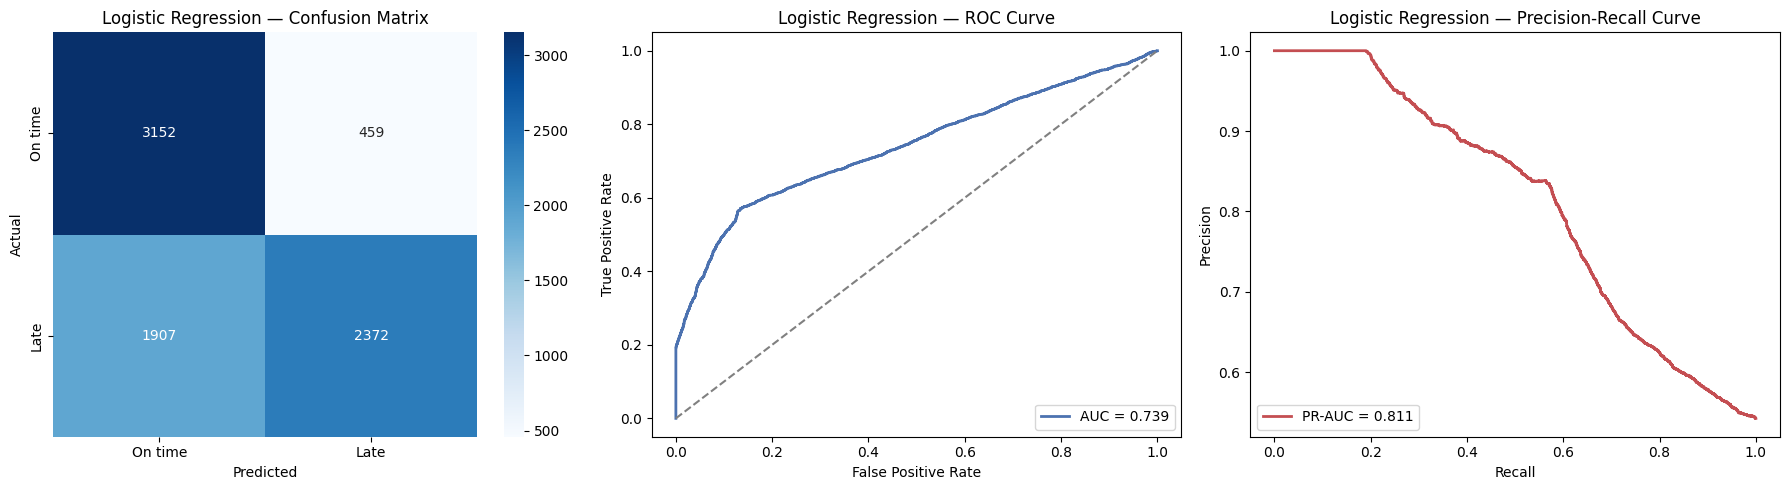

In [13]:
logreg_metrics = evaluate_and_plot(y_val, y_pred, y_score, 'Logistic Regression', save_prefix='logreg')


**What we found:**

**A modest but real, consistent improvement over the rule based baseline across every metric:**

| Metric | Baseline | Logistic Regression | Change |
|---|---|---|---|
| Recall | 0.5349 | 0.5543 | +0.019 |
| Precision | 0.8391 | 0.8379 | -0.001 |
| F1 | 0.6533 | 0.6672 | +0.014 |
| ROC-AUC | 0.7270 | 0.7394 | +0.012 |
| PR-AUC | 0.7429 | 0.8105 | **+0.068** |

Recall, F1, and ROC-AUC all improved slightly while Precision held essentially flat, no tradeoff was made to get the small Recall gain, which is a clean result. The standout is **PR-AUC, up nearly 7 points**, meaning the full set of 27 features gives Logistic Regression a meaningfully better *ranking* of orders by risk across all possible thresholds, even though the improvement at the default 0.5 threshold looks modest. This matters directly for Stage 8, where we plan to tune the classification threshold for cost sensitivity rather than leaving it at 0.5, a strong PR-AUC suggests there's real room to improve Recall further by adjusting the threshold down, since the model is ranking orders well even if the default cutoff undersells it.


## 3. Coefficients (interpretability)

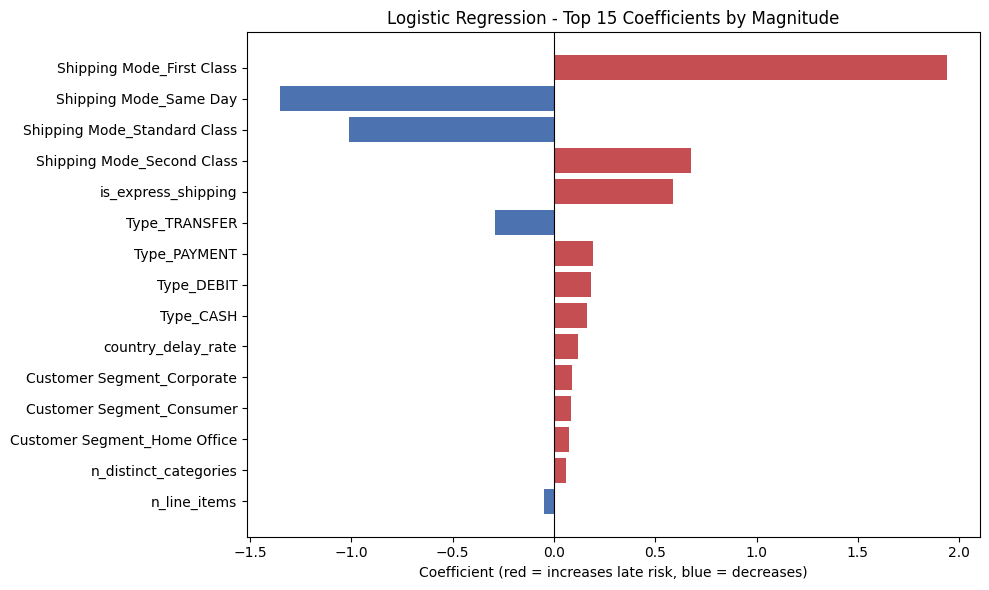

In [15]:
import matplotlib.pyplot as plt

coef_df = pd.DataFrame({'feature': X_train.columns, 'coefficient': log_reg.coef_[0]})
coef_df = coef_df.sort_values('coefficient', key=abs, ascending=False).head(15)

plt.figure(figsize=(10, 6))
colors = ['#C44E52' if c > 0 else '#4C72B0' for c in coef_df['coefficient']]
plt.barh(coef_df['feature'], coef_df['coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Coefficient (red = increases late risk, blue = decreases)')
plt.title('Logistic Regression - Top 15 Coefficients by Magnitude')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../../../reports/figures/logreg_coefficients.png', dpi=120, bbox_inches='tight')
plt.show()


**What we found:**

**Shipping Mode dominates completely, exactly as EDA predicted**, and by a wide margin: `Shipping Mode_First Class` has by far the largest coefficient (+1.94), followed by `Shipping Mode_Same Day` (-1.33) and `Shipping Mode_Standard Class` (-1.00) pulling risk down, and `Shipping Mode_Second Class` (+0.68) and `is_express_shipping` (+0.58) also pulling it up. This lines up directly with the 57-percentage-point spread found in EDA and confirms Logistic Regression is picking up the same dominant signal the raw data showed.

**One genuinely interesting cross check finding:** `country_delay_rate` (EDA's second-strongest univariate signal, a 30 point spread) shows only a modest coefficient here (~0.1), and `region_delay_rate` doesn't even appear in the top 15. This isn't a contradiction of the EDA finding, it's the expected difference between a univariate spread (how much late rate varies by country *on its own*) and a multivariate coefficient (how much country adds *once Shipping Mode and everything else is already accounted for*). Since Shipping Mode already explains so much of the variance, the geographic features contribute comparatively less *additional* information in a combined model, even though they're individually meaningful. Worth stating this distinction explicitly if asked in a viva why the "second strongest EDA feature" doesn't show up as the second strongest coefficient.

**A smaller, worth noting detail:** payment `Type` (CASH/DEBIT/PAYMENT/TRANSFER) shows small but consistent effects, all in the same direction except TRANSFER (slightly negative). This is a legitimate order time known feature, and while its effect is minor compared to Shipping Mode, it's not nothing, worth keeping in the feature set rather than dismissing it as noise.


## 4. Save model and metrics

In [16]:
joblib.dump(log_reg, '../../../models/logistic_regression.pkl')
save_metrics(logreg_metrics, '../../../data/processed/metrics_logreg.json')


Saved metrics to ../../../data/processed/metrics_logreg.json
